### Library import

In [1]:
import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from fpdf import FPDF
from datetime import datetime
import requests
import warnings
warnings.filterwarnings('ignore')

### Specify the main path to the project folder

In [2]:
base_path = r'C:\Users\ps\Desktop\Final project'

### Select spectral beam files (Red, Green, Blue) from a Landsat 8 image for use in creating a natural color image (True Color)

In [3]:
b4_file = 'LC09_L1TP_226061_20250319_20250319_02_T1_B4.TIF'  # Red (أحمر)
b3_file = 'LC09_L1TP_226061_20250319_20250319_02_T1_B3.TIF'  # Green (أخضر)
b2_file = 'LC09_L1TP_226061_20250319_20250319_02_T1_B2.TIF'  # Blue (أزرق)

### Create the full path to the spectral packet files (B4, B3, B2) within the working folder, then display the filenames used for the Landsat image

In [4]:
b4_path = os.path.join(base_path, b4_file)
b3_path = os.path.join(base_path, b3_file)
b2_path = os.path.join(base_path, b2_file)

print(f"\n📁 مجلد العمل: {base_path}")
print(f"\n📄 ملفات Landsat 8:")
print(f"   🔴 B4 (أحمر): {b4_file}")
print(f"   🟢 B3 (أخضر): {b3_file}")
print(f"   🔵 B2 (أزرق): {b2_file}")


📁 مجلد العمل: C:\Users\ps\Desktop\Final project

📄 ملفات Landsat 8:
   🔴 B4 (أحمر): LC09_L1TP_226061_20250319_20250319_02_T1_B4.TIF
   🟢 B3 (أخضر): LC09_L1TP_226061_20250319_20250319_02_T1_B3.TIF
   🔵 B2 (أزرق): LC09_L1TP_226061_20250319_20250319_02_T1_B2.TIF


### Verify that all required spectral package files (B4, B3, B2) are present in the working folder and stop the program if any file is missing

In [5]:
missing_files = []
for file_path in [b4_path, b3_path, b2_path]:
    if not os.path.exists(file_path):
        missing_files.append(file_path)

if missing_files:
    print("\n❌ الملفات التالية غير موجودة:")
    for file in missing_files:
        print(f"   - {file}")
    print("\n📂 الملفات الموجودة في المجلد:")
    for file in os.listdir(base_path):
        print(f"   - {file}")
    sys.exit(1)
else:
    print("\n✅ تم العثور على جميع ملفات Landsat 8")


✅ تم العثور على جميع ملفات Landsat 8


In [6]:
print("\n" + "="*70)
print("📖 قراءة المرئيات الفضائية باستخدام rasterio")
print("="*70)


📖 قراءة المرئيات الفضائية باستخدام rasterio


### Opening the red band file (B4) using the rasterio library to read the data and extract basic image information such as dimensions, borders, and coordinate system

In [8]:
with rasterio.open(b4_path) as src:
    red_band = src.read(1)
    red_profile = src.profile
    print(f"\n🔴 الباند الأحمر (B4):")
    print(f"   📐 الأبعاد: {src.width} x {src.height}")
    print(f"   📏 المدى: {src.bounds}")
    print(f"   🗺️ نظام الإحداثيات: {src.crs}")


🔴 الباند الأحمر (B4):
   📐 الأبعاد: 7591 x 7731
   📏 المدى: BoundingBox(left=217185.0, bottom=-276315.0, right=444915.0, top=-44385.0)
   🗺️ نظام الإحداثيات: EPSG:32622


### Open the green band file (B3) using rasterio to read the packet data and display the image dimensions

In [9]:
with rasterio.open(b3_path) as src:
    green_band = src.read(1)
    print(f"\n🟢 الباند الأخضر (B3):")
    print(f"   📐 الأبعاد: {src.width} x {src.height}")


🟢 الباند الأخضر (B3):
   📐 الأبعاد: 7591 x 7731


### Open the blue band file (B2) using rasterio to read the packet data and display the image dimensions

In [10]:
with rasterio.open(b2_path) as src:
    blue_band = src.read(1)
    print(f"\n🔵 الباند الأزرق (B2):")
    print(f"   📐 الأبعاد: {src.width} x {src.height}")


🔵 الباند الأزرق (B2):
   📐 الأبعاد: 7591 x 7731


### Checking the dimensions of the three bands (B4, B3, B2) are identical, and if they differ, they are standardized by cutting them to the smallest common dimensions.

In [11]:
if red_band.shape == green_band.shape == blue_band.shape:
    height, width = red_band.shape
    print(f"\n✅ جميع الباندات بنفس الأبعاد: {height} x {width}")
else:
    print("\n❌ أبعاد الباندات غير متطابقة!")
    print(f"   B4: {red_band.shape}")
    print(f"   B3: {green_band.shape}")
    print(f"   B2: {blue_band.shape}")
    # توحيد الأبعاد (أخذ أصغر الأبعاد)
    min_height = min(red_band.shape[0], green_band.shape[0], blue_band.shape[0])
    min_width = min(red_band.shape[1], green_band.shape[1], blue_band.shape[1])
    red_band = red_band[:min_height, :min_width]
    green_band = green_band[:min_height, :min_width]
    blue_band = blue_band[:min_height, :min_width]
    height, width = min_height, min_width
    print(f"✅ تم توحيد الأبعاد إلى: {height} x {width}")


✅ جميع الباندات بنفس الأبعاد: 7731 x 7591


### Displays basic statistics for the three bands (Red, Green, Blue) such as minimum, maximum, and average values

In [12]:
print(f"\n📊 إحصائيات الباندات:")
for band_name, band_data in [('Red', red_band), ('Green', green_band), ('Blue', blue_band)]:
    print(f"   {band_name}: المدى = {band_data.min():.0f} - {band_data.max():.0f}, المتوسط = {band_data.mean():.2f}")


📊 إحصائيات الباندات:
   Red: المدى = 0 - 65446, المتوسط = 12702.86
   Green: المدى = 0 - 62797, المتوسط = 12967.77
   Blue: المدى = 0 - 62517, المتوسط = 13715.05


### Combining the three bands (Red, Green, Blue) to create a natural color image (RGB) as a 3D matrix

In [13]:
rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)

### Image preparation for display: If the values ​​are greater than 255, they are converted to the range 0-255 and then converted to uint8; otherwise, they are converted directly.

In [14]:
if rgb_image.max() > 255:
    rgb_display = (rgb_image / rgb_image.max() * 255).astype(np.uint8)
else:
    rgb_display = rgb_image.astype(np.uint8)

### Displaying a natural color image (RGB) using matplotlib with axes removed and a title added

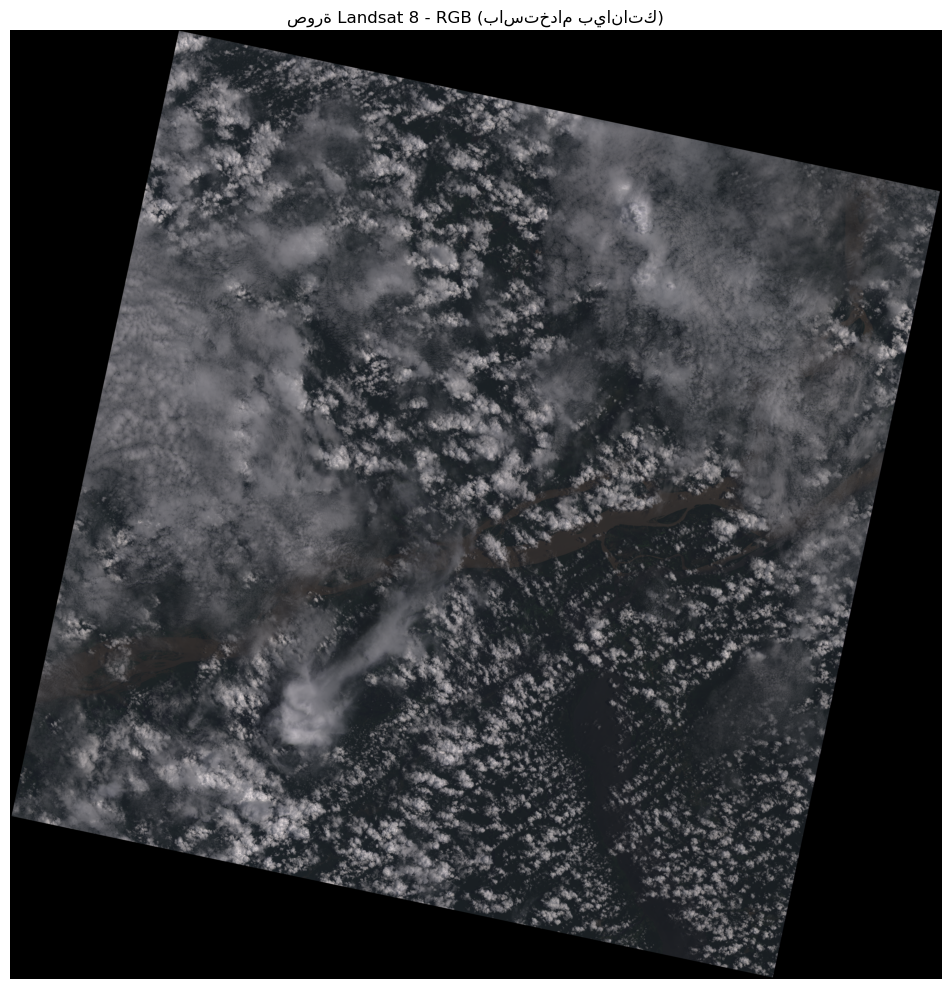

In [15]:
plt.figure(figsize=(15, 10))
plt.imshow(rgb_display)
plt.title('صورة Landsat 8 - RGB (باستخدام بياناتك)')
plt.axis('off')
plt.tight_layout()
plt.show()

In [16]:
print("\n" + "="*70)
print("🔄 تحويل الصورة إلى مصفوفة Training Data")
print("="*70)


🔄 تحويل الصورة إلى مصفوفة Training Data


### Convert the three bands (Red, Green, Blue) into a two-dimensional Features array (each row represents a pixel and each column represents a band)

In [17]:
X_full = np.column_stack([
    red_band.reshape(-1),   # الباند الأحمر
    green_band.reshape(-1), # الباند الأخضر
    blue_band.reshape(-1)   # الباند الأزرق
])

print(f"📊 مصفوفة Features (X_full): {X_full.shape}")
print(f"   - عدد البكسلات الكلي: {X_full.shape[0]:,}")
print(f"   - عدد الخصائص (باندات): {X_full.shape[1]}")
print(f"\n📈 إحصائيات الباندات:")

📊 مصفوفة Features (X_full): (58686021, 3)
   - عدد البكسلات الكلي: 58,686,021
   - عدد الخصائص (باندات): 3

📈 إحصائيات الباندات:


### Calculate and display statistics for each band (mean, standard deviation, minimum, and maximum) using the Features X_full matrix

In [18]:
band_stats = []
for i, band_name in enumerate(['Red (B4)', 'Green (B3)', 'Blue (B2)']):
    mean_val = X_full[:, i].mean()
    std_val = X_full[:, i].std()
    min_val = X_full[:, i].min()
    max_val = X_full[:, i].max()
    band_stats.append({
        'Band': band_name,
        'Mean': mean_val,
        'Std': std_val,
        'Min': min_val,
        'Max': max_val
    })
    print(f"   {band_name}: المدى = {min_val:.2f} - {max_val:.2f}, المتوسط = {mean_val:.2f}")


   Red (B4): المدى = 0.00 - 65446.00, المتوسط = 12702.86
   Green (B3): المدى = 0.00 - 62797.00, المتوسط = 12967.77
   Blue (B2): المدى = 0.00 - 62517.00, المتوسط = 13715.05


### Presentation of information on the creation of Ground Truth data and land use classifications, with an explanation of the spectral values for each band in each category.

In [19]:
print("\n" + "="*70)
print("📝 إنشاء بيانات Ground Truth")
print("="*70)

print("""
التصنيفات المستخدمة:
0: 🏙️ مناطق عمرانية (Urban) - قيم متوسطة في جميع الباندات
1: 🌾 مناطق زراعية (Agricultural) - أخضر عالي، أحمر منخفض
2: 💧 مسطحات مائية (Water) - أزرق عالي، أحمر منخفض جداً
""")


📝 إنشاء بيانات Ground Truth

التصنيفات المستخدمة:
0: 🏙️ مناطق عمرانية (Urban) - قيم متوسطة في جميع الباندات
1: 🌾 مناطق زراعية (Agricultural) - أخضر عالي، أحمر منخفض
2: 💧 مسطحات مائية (Water) - أزرق عالي، أحمر منخفض جداً



### Adjusting the random seed to replicate results and determining the number of samples per classification (increasing the number to balance the data)

In [20]:
np.random.seed(42)
n_samples_per_class = 3000  # زيادة عدد العينات
total_samples = n_samples_per_class * 3

### Selecting random samples from the Features X_full array to generate Ground Truth training data

In [21]:
random_indices = np.random.choice(X_full.shape[0], total_samples, replace=False)
X_samples = X_full[random_indices]

### Create an initial label array for all samples as zero, which will be updated later for each category

In [22]:
y_samples = np.zeros(total_samples)

### Classifying random samples into land use categories (Urban, Agricultural, Water) based on the spectral values of pixels in the red, green, and blue bands

In [23]:
for i, idx in enumerate(random_indices):
    r, g, b = X_full[idx]
    
    if b > 100 and r < 130 and g < 130:  # Water
        y_samples[i] = 2
    elif g > 100 and g > r * 1.1:       # Agricultural
        y_samples[i] = 1
    else:                               # Urban
        y_samples[i] = 0

### Calculation and display of the distribution of classified samples for each category (Urban, Agricultural, Water), their number, and the percentage of each category out of the total samples

In [24]:
unique, counts = np.unique(y_samples, return_counts=True)
class_counts = dict(zip(unique, counts))

print(f"\n📊 توزيع العينات:")
for class_id in [0, 1, 2]:
    class_name = ['Urban', 'Agricultural', 'Water'][class_id]
    count = class_counts.get(class_id, 0)
    print(f"   {class_name}: {count} عينة ({count/total_samples*100:.1f}%)")


📊 توزيع العينات:
   Urban: 7759 عينة (86.2%)
   Agricultural: 1241 عينة (13.8%)
   Water: 0 عينة (0.0%)


### Create a DataFrame to group samples with bands, numeric values, and text labels for each category

In [25]:
training_df = pd.DataFrame(X_samples, columns=['Red', 'Green', 'Blue'])
training_df['Class'] = y_samples.astype(int)
training_df['Class_Name'] = training_df['Class'].map({0: 'Urban', 1: 'Agricultural', 2: 'Water'})

### Create a 'processed' folder inside the work folder and save the training samples' DataFrame as a CSV file

In [26]:
processed_path = os.path.join(base_path, 'processed')
os.makedirs(processed_path, exist_ok=True)

csv_path = os.path.join(processed_path, 'training_samples.csv')
training_df.to_csv(csv_path, index=False)
print(f"\n✅ تم حفظ عينات التدريب في: {csv_path}")


✅ تم حفظ عينات التدريب في: C:\Users\ps\Desktop\Final project\processed\training_samples.csv


In [27]:
print("\n" + "="*70)
print("📊 تقسيم البيانات")
print("="*70)


📊 تقسيم البيانات


### Divide the data into a training set (70%) and a temporary set (30%) while maintaining the class distribution using Stratify

In [28]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_samples, y_samples, 
    test_size=0.3, 
    random_state=42,
    stratify=y_samples
)

### Divide the provisional group equally into two groups: Validation and Test, while maintaining the distribution of categories.

In [29]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

### Display the number of samples for each category in the training set and their percentage

In [30]:
print(f"📚 بيانات التدريب (Training): {X_train.shape[0]} عينة")
print(f"   Urban: {np.sum(y_train == 0)} ({np.sum(y_train == 0)/len(y_train)*100:.1f}%)")
print(f"   Agricultural: {np.sum(y_train == 1)} ({np.sum(y_train == 1)/len(y_train)*100:.1f}%)")
print(f"   Water: {np.sum(y_train == 2)} ({np.sum(y_train == 2)/len(y_train)*100:.1f}%)")

📚 بيانات التدريب (Training): 6300 عينة
   Urban: 5431 (86.2%)
   Agricultural: 869 (13.8%)
   Water: 0 (0.0%)


### Display the number of samples for each category in the validation set and their percentage

In [31]:
print(f"\n📋 بيانات التحقق (Validation): {X_val.shape[0]} عينة")
print(f"   Urban: {np.sum(y_val == 0)} ({np.sum(y_val == 0)/len(y_val)*100:.1f}%)")
print(f"   Agricultural: {np.sum(y_val == 1)} ({np.sum(y_val == 1)/len(y_val)*100:.1f}%)")
print(f"   Water: {np.sum(y_val == 2)} ({np.sum(y_val == 2)/len(y_val)*100:.1f}%)")


📋 بيانات التحقق (Validation): 1350 عينة
   Urban: 1164 (86.2%)
   Agricultural: 186 (13.8%)
   Water: 0 (0.0%)


### Display the number of samples for each category in the test set and their percentage

In [32]:
print(f"\n📋 بيانات الاختبار (Test): {X_test.shape[0]} عينة")
print(f"   Urban: {np.sum(y_test == 0)} ({np.sum(y_test == 0)/len(y_test)*100:.1f}%)")
print(f"   Agricultural: {np.sum(y_test == 1)} ({np.sum(y_test == 1)/len(y_test)*100:.1f}%)")
print(f"   Water: {np.sum(y_test == 2)} ({np.sum(y_test == 2)/len(y_test)*100:.1f}%)")


📋 بيانات الاختبار (Test): 1350 عينة
   Urban: 1164 (86.2%)
   Agricultural: 186 (13.8%)
   Water: 0 (0.0%)


In [33]:
print("\n" + "="*70)
print("🌳 تدريب نموذج Decision Tree مع Grid Search")
print("="*70)


🌳 تدريب نموذج Decision Tree مع Grid Search


### Create a basic decision tree model and adjust the random seed to ensure the reproducibility of results

In [34]:
dt_base = DecisionTreeClassifier(random_state=42)

### Setting up a grid search to identify the best parameters for a decision tree using cross-validation (5-fold CV)

In [35]:
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [10, 20, 30, 50],
    'min_samples_leaf': [5, 10, 15],
    'class_weight': ['balanced', None]
}

print("🔍 جاري البحث عن أفضل المعاملات...")
grid_search = GridSearchCV(
    dt_base, 
    param_grid, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

🔍 جاري البحث عن أفضل المعاملات...


### Grid Search training on training data to find the best parameters for the decision tree and display the results

In [36]:
grid_search.fit(X_train, y_train)

print(f"\n✅ أفضل المعاملات:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"   أفضل دقة Cross-validation: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 96 candidates, totalling 480 fits

✅ أفضل المعاملات:
   class_weight: None
   max_depth: 15
   min_samples_leaf: 5
   min_samples_split: 10
   أفضل دقة Cross-validation: 0.9822


### Extracting the best decision tree model after Grid Search for evaluation on validation and testing data.

In [37]:
best_dt = grid_search.best_estimator_

### Demonstrate the importance of each band (Red, Green, Blue) in the decision tree model after training

In [38]:
feature_importance = best_dt.feature_importances_
print(f"\n📊 أهمية الباندات:")
for i, (band, imp) in enumerate(zip(['Red', 'Green', 'Blue'], feature_importance)):
    print(f"   {band}: {imp:.4f} ({imp*100:.1f}%)")


📊 أهمية الباندات:
   Red: 0.3359 (33.6%)
   Green: 0.1260 (12.6%)
   Blue: 0.5380 (53.8%)


In [41]:
print("\n" + "="*70)
print("📈 مقاييس أداء النموذج")
print("="*70)


📈 مقاييس أداء النموذج


### Defining the names of numerical and text categories to facilitate their use in evaluating the model and displaying the results

In [43]:
class_names = ['Urban', 'Agricultural', 'Water']
all_classes = [0, 1, 2]  # القيم الرقمية المقابلة لكل فئة

### Using the best model to predict categories on training, verification, and testing groups

In [44]:
y_train_pred = best_dt.predict(X_train)
y_val_pred = best_dt.predict(X_val)
y_test_pred = best_dt.predict(X_test)

### A function to print performance metrics (Accuracy, Precision, Recall, F1-Score) for any dataset with missing categories handling

In [45]:
def print_metrics(y_true, y_pred, dataset_name):
    """طباعة مقاييس الأداء لمجموعة بيانات مع معالجة الفئات المفقودة"""
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0, labels=all_classes)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0, labels=all_classes)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0, labels=all_classes)
    
    print(f"\n📊 {dataset_name}:")
    print(f"   ✅ Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   ✅ Precision: {precision:.4f}")
    print(f"   ✅ Recall: {recall:.4f}")
    print(f"   ✅ F1-Score: {f1:.4f}")
    
    return accuracy, precision, recall, f1

### Calculate and print performance metrics for training, verification, and testing groups using the print_metrics function

In [46]:
train_metrics = print_metrics(y_train, y_train_pred, "نتائج التدريب (Training)")
val_metrics = print_metrics(y_val, y_val_pred, "نتائج التحقق (Validation)")
test_metrics = print_metrics(y_test, y_test_pred, "نتائج الاختبار (Test)")


📊 نتائج التدريب (Training):
   ✅ Accuracy: 0.9935 (99.35%)
   ✅ Precision: 0.9935
   ✅ Recall: 0.9935
   ✅ F1-Score: 0.9935

📊 نتائج التحقق (Validation):
   ✅ Accuracy: 0.9867 (98.67%)
   ✅ Precision: 0.9868
   ✅ Recall: 0.9867
   ✅ F1-Score: 0.9867

📊 نتائج الاختبار (Test):
   ✅ Accuracy: 0.9844 (98.44%)
   ✅ Precision: 0.9846
   ✅ Recall: 0.9844
   ✅ F1-Score: 0.9845


### Creating and displaying the Confusion Matrix for the test set using Seaborn

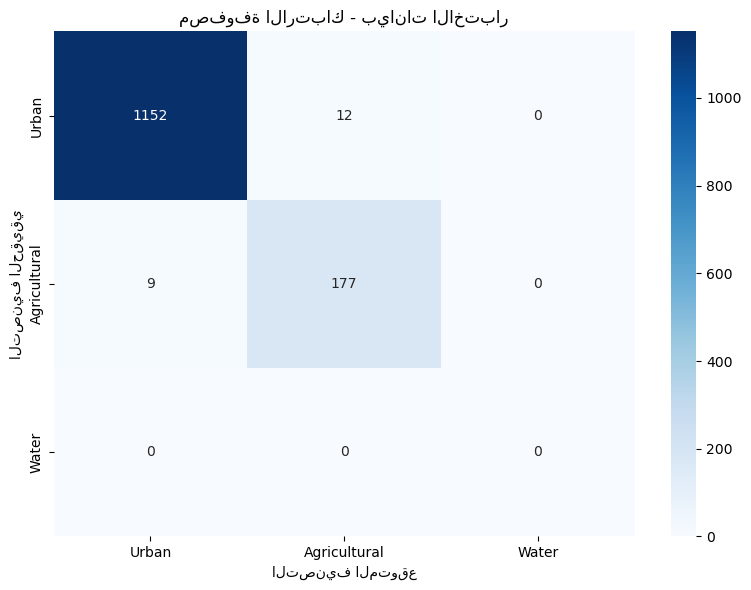

In [47]:
conf_matrix = confusion_matrix(y_test, y_test_pred, labels=all_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('مصفوفة الارتباك - بيانات الاختبار')
plt.xlabel('التصنيف المتوقع')
plt.ylabel('التصنيف الحقيقي')
plt.tight_layout()
plt.show()

### Display a detailed classification report for the test group with accuracy, recall, and F1-Score for each category

In [48]:
print("\n📋 تقرير التصنيف المفصل (Test Set):")
print(classification_report(y_test, y_test_pred, 
                          labels=all_classes,
                          target_names=class_names, 
                          zero_division=0))


📋 تقرير التصنيف المفصل (Test Set):
              precision    recall  f1-score   support

       Urban       0.99      0.99      0.99      1164
Agricultural       0.94      0.95      0.94       186
       Water       0.00      0.00      0.00         0

   micro avg       0.98      0.98      0.98      1350
   macro avg       0.64      0.65      0.64      1350
weighted avg       0.98      0.98      0.98      1350



In [49]:
print("\n" + "="*70)
print("🖼️ تطبيق النموذج على الصورة كاملة")
print("="*70)


🖼️ تطبيق النموذج على الصورة كاملة


### Using the best model to classify all image pixels and convert them into a complete classification matrix

In [50]:
print("🔄 جاري تصنيف جميع البكسلات...")
y_full_pred = best_dt.predict(X_full)
print(f"✅ تم تصنيف {len(y_full_pred):,} بكسل")

🔄 جاري تصنيف جميع البكسلات...
✅ تم تصنيف 58,686,021 بكسل


### Reforming the prediction matrix to create a classification map with the original image dimensions

In [51]:
classification_map = y_full_pred.reshape(height, width)

### Displaying results in a three-column format:
### 1) Original RGB image,
### 2) Decision Tree classification map for each category in a different color with legend,
### 3) Overlay between the original image and classification map to show classification results on the actual image

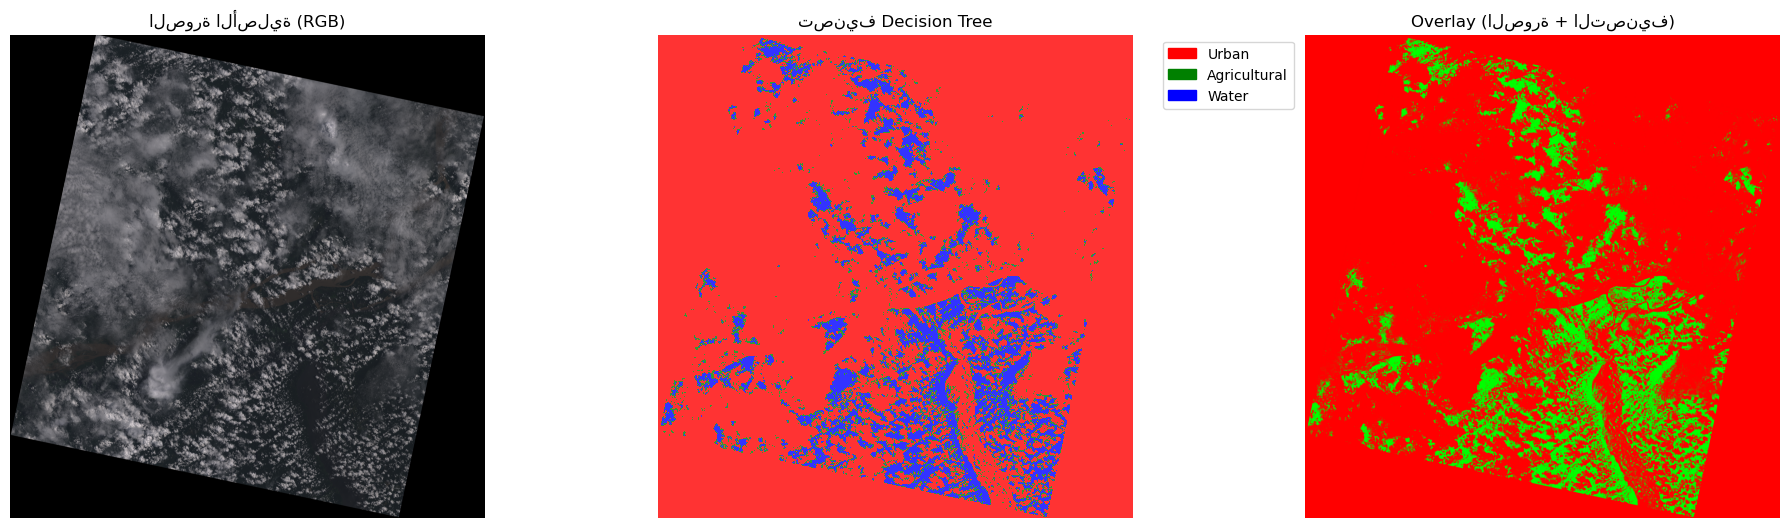

In [52]:
# إنشاء شكل به 3 أعمدة
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# الصورة الأصلية
axes[0].imshow(rgb_display)
axes[0].set_title('الصورة الأصلية (RGB)')
axes[0].axis('off')

# خريطة التصنيف
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['red', 'green', 'blue'])
im = axes[1].imshow(classification_map, cmap=cmap, alpha=0.8)
axes[1].set_title('تصنيف Decision Tree')
axes[1].axis('off')

# وسيلة إيضاح لخريطة التصنيف
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color='red', label='Urban'),
           mpatches.Patch(color='green', label='Agricultural'),
           mpatches.Patch(color='blue', label='Water')]
axes[1].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

# Overlay (الصورة + التصنيف)
overlay = rgb_display.copy()
overlay[classification_map == 0] = [255, 0, 0]      # Urban - أحمر
overlay[classification_map == 1] = [0, 255, 0]      # Agricultural - أخضر
overlay[classification_map == 2] = [0, 0, 255]      # Water - أزرق
axes[2].imshow(overlay)
axes[2].set_title('Overlay (الصورة + التصنيف)')
axes[2].axis('off')

# ضبط المسافات وعرض الشكل
plt.tight_layout()
plt.show()

In [53]:
print("\n" + "="*70)
print("💾 حفظ النموذج والملفات")
print("="*70)


💾 حفظ النموذج والملفات


### Create folders to save trained models and output/classification maps within the work folder

In [54]:
models_path = os.path.join(base_path, 'models')
output_path = os.path.join(base_path, 'output')
os.makedirs(models_path, exist_ok=True)
os.makedirs(output_path, exist_ok=True)

### حفظ نموذج شجرة القرار الأفضل بعد التدريب كملف .pkl باستخدام joblib

In [55]:
model_path = os.path.join(models_path, 'decision_tree_model.pkl')
joblib.dump(best_dt, model_path)
print(f"✅ تم حفظ النموذج في: {model_path}")

✅ تم حفظ النموذج في: C:\Users\ps\Desktop\Final project\models\decision_tree_model.pkl


### Create a dictionary to store important model information such as class names, bands used, accuracy for each group, importance of properties, best coefficients, and number of samples

In [56]:
model_info = {
    'class_names': class_names,
    'bands_used': ['Red', 'Green', 'Blue'],
    'accuracy_train': train_metrics[0],
    'accuracy_val': val_metrics[0],
    'accuracy_test': test_metrics[0],
    'feature_importance': feature_importance.tolist(),
    'best_params': grid_search.best_params_,
    'n_samples': {
        'train': len(X_train),
        'val': len(X_val),
        'test': len(X_test)
    }
}

### Save the model information dictionary as a .pkl file for later use or to review model performance

In [57]:
info_path = os.path.join(models_path, 'model_info.pkl')
joblib.dump(model_info, info_path)
print(f"✅ تم حفظ معلومات النموذج في: {info_path}")

✅ تم حفظ معلومات النموذج في: C:\Users\ps\Desktop\Final project\models\model_info.pkl


### Save the classification map as a GeoTIFF image using the same properties as the original image, then view a summary of the generated files.

In [59]:
classified_path = os.path.join(output_path, 'classified_image.tif')

with rasterio.open(b4_path) as src:
    profile = src.profile
    profile.update(
        count=1,
        dtype='uint8',
        compress='lzw'
    )
    
    with rasterio.open(classified_path, 'w', **profile) as dst:
        dst.write(classification_map.astype('uint8'), 1)

print(f"✅ تم حفظ الصورة المصنفة في: {classified_path}")

print("\n" + "="*70)
print("🎉 الجزء الأول اكتمل بنجاح!")
print("="*70)
print(f"""
الملفات التي تم إنشاؤها:
1. 📁 النموذج: {model_path}
2. ℹ️ معلومات النموذج: {info_path}
3. 🖼️ الصورة المصنفة: {classified_path}
4. 📊 عينات التدريب: {csv_path}

""")

✅ تم حفظ الصورة المصنفة في: C:\Users\ps\Desktop\Final project\output\classified_image.tif

🎉 الجزء الأول اكتمل بنجاح!

الملفات التي تم إنشاؤها:
1. 📁 النموذج: C:\Users\ps\Desktop\Final project\models\decision_tree_model.pkl
2. ℹ️ معلومات النموذج: C:\Users\ps\Desktop\Final project\models\model_info.pkl
3. 🖼️ الصورة المصنفة: C:\Users\ps\Desktop\Final project\output\classified_image.tif
4. 📊 عينات التدريب: C:\Users\ps\Desktop\Final project\processed\training_samples.csv


